# Retail Sales Forecasting & Demand Planning with an AI Business Chat Assistant

**AICTE | IBM SkillsBuild Data Analytics with AI Internship 2026 | BharatCares**

### Project objective
Build an end-to-end retail analytics solution that converts transaction data into:
- sales and demand KPIs,
- product/customer/country insights,
- a short-term demand/revenue forecast,
- inventory planning recommendations, and
- an AI-style natural-language business question assistant.

**Author:** Yash


## 1. Business Problem

Retail teams need to answer two questions quickly:

1. **What happened?** — sales, demand, products, customers and markets.
2. **What is likely to happen next?** — short-term demand/revenue and stock-planning signals.

This notebook develops a reproducible analytics pipeline and a lightweight AI assistant that allows a manager to ask business questions in plain English.


In [1]:
# 2. Imports and configuration
import warnings, re, zipfile, urllib.request, io
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

RANDOM_STATE = 42
FORECAST_HORIZON = 30

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


## 3. Data Loading

The primary dataset is the **UCI Online Retail Dataset**. The code tries to download it automatically. If internet access is unavailable, a realistic synthetic retail dataset is generated so that the project remains fully runnable.

Public dataset: https://archive.ics.uci.edu/dataset/352/online+retail


In [2]:
# 3.1 Load UCI Online Retail when available; otherwise generate a realistic synthetic dataset

UCI_URL = "https://archive.ics.uci.edu/static/public/352/online+retail.zip"

def make_synthetic_retail(n_days=720, seed=42):
    rng = np.random.default_rng(seed)
    dates = pd.date_range("2024-01-01", periods=n_days, freq="D")
    products = [
        ("P001","Classic Mug",8.50), ("P002","Ceramic Plate",12.00),
        ("P003","Tea Set",24.00), ("P004","Lunch Box",15.50),
        ("P005","Water Bottle",18.00), ("P006","Storage Jar",10.00),
        ("P007","Gift Bag",4.50), ("P008","Kitchen Towel",7.00),
        ("P009","Serving Tray",21.00), ("P010","Coffee Spoon",5.50)
    ]
    countries = ["United Kingdom","Ireland","Germany","France","Spain","Netherlands"]
    rows = []
    invoice_no = 100000
    for i, d in enumerate(dates):
        weekly = 1 + 0.18*np.sin(2*np.pi*d.dayofweek/7)
        seasonal = 1 + 0.12*np.sin(2*np.pi*i/365)
        trend = 1 + 0.00045*i
        n_orders = max(10, int(rng.poisson(55 * weekly * seasonal * trend)))
        for _ in range(n_orders):
            pid, desc, price = products[rng.integers(len(products))]
            qty = int(max(1, rng.poisson(3.2)))
            country = countries[rng.integers(len(countries))]
            customer = int(rng.integers(10000, 10300))
            rows.append([f"{invoice_no}", pid, desc, qty, d + pd.Timedelta(minutes=int(rng.integers(0,1440))),
                         price * rng.uniform(0.9,1.1), customer, country])
            invoice_no += 1
    return pd.DataFrame(rows, columns=[
        "InvoiceNo","StockCode","Description","Quantity","InvoiceDate",
        "UnitPrice","CustomerID","Country"
    ])

try:
    raw_bytes = urllib.request.urlopen(UCI_URL, timeout=20).read()
    z = zipfile.ZipFile(io.BytesIO(raw_bytes))
    excel_name = [n for n in z.namelist() if n.lower().endswith((".xlsx",".xls"))][0]
    data = pd.read_excel(io.BytesIO(z.read(excel_name)))
    print("Loaded UCI Online Retail dataset:", data.shape)
except Exception as e:
    data = make_synthetic_retail()
    print("Online dataset unavailable; using generated demonstration dataset:", data.shape)


Online dataset unavailable; using generated demonstration dataset: (45584, 8)


In [3]:
# 3.2 Standardise column names and inspect
data.columns = [str(c).strip() for c in data.columns]

rename_map = {
    "Invoice": "InvoiceNo",
    "Invoice Date": "InvoiceDate",
    "Price": "UnitPrice",
    "Customer ID": "CustomerID",
    "Stock Code": "StockCode",
    "Description": "Description",
    "Quantity": "Quantity",
    "Country": "Country"
}
data = data.rename(columns={k:v for k,v in rename_map.items() if k in data.columns})

print(data.head())
print("\nShape:", data.shape)
print("\nMissing values:")
print(data.isna().sum().sort_values(ascending=False).head(10))


  InvoiceNo StockCode   Description  Quantity         InvoiceDate  UnitPrice  \
0    100000      P005  Water Bottle         4 2024-01-01 03:04:00      17.82   
1    100001      P006   Storage Jar         5 2024-01-01 01:31:00      10.66   
2    100002      P003       Tea Set         5 2024-01-01 11:12:00      21.81   
3    100003      P006   Storage Jar         5 2024-01-01 04:32:00       9.26   
4    100004      P007      Gift Bag         4 2024-01-01 07:29:00       4.80   

   CustomerID         Country  
0       10153     Netherlands  
1       10266         Germany  
2       10109          France  
3       10238  United Kingdom  
4       10029         Germany  

Shape: (45584, 8)

Missing values:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


## 4. Data Cleaning & Feature Engineering

Business rules:
- remove cancelled invoices where possible,
- remove non-positive quantities and prices,
- remove records without a product description,
- convert invoice date to datetime,
- calculate line-level revenue.


In [4]:
# 4.1 Clean transaction data
df = data.copy()

if "InvoiceNo" in df.columns:
    df["InvoiceNo"] = df["InvoiceNo"].astype(str)
    df = df[~df["InvoiceNo"].str.upper().str.startswith("C")]

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["UnitPrice"] = pd.to_numeric(df["UnitPrice"], errors="coerce")

df = df.dropna(subset=["InvoiceDate","Quantity","UnitPrice","Description"])
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]
df["Revenue"] = df["Quantity"] * df["UnitPrice"]
df["Date"] = df["InvoiceDate"].dt.floor("D")

if "CustomerID" in df.columns:
    df["CustomerID"] = df["CustomerID"].astype(str).replace("nan", np.nan)

print("Cleaned rows:", len(df))
print("Date range:", df["Date"].min().date(), "to", df["Date"].max().date())


Cleaned rows: 45584
Date range: 2024-01-01 to 2025-12-20


In [5]:
# 4.2 Core KPIs
total_revenue = df["Revenue"].sum()
total_units = df["Quantity"].sum()
orders = df["InvoiceNo"].nunique()
customers = df["CustomerID"].nunique() if "CustomerID" in df.columns else np.nan
avg_order_value = total_revenue / orders

kpis = pd.DataFrame({
    "Metric": ["Total Revenue","Units Sold","Orders","Customers","Average Order Value"],
    "Value": [total_revenue,total_units,orders,customers,avg_order_value]
})
kpis


,Metric,Value
0,Total Revenue,"1,861,353.89"
1,Units Sold,"147,836.00"
2,Orders,"45,584.00"
3,Customers,300.00
4,Average Order Value,40.83


## 5. Exploratory Data Analysis

The following views answer the main management questions: revenue trend, product performance and market performance.


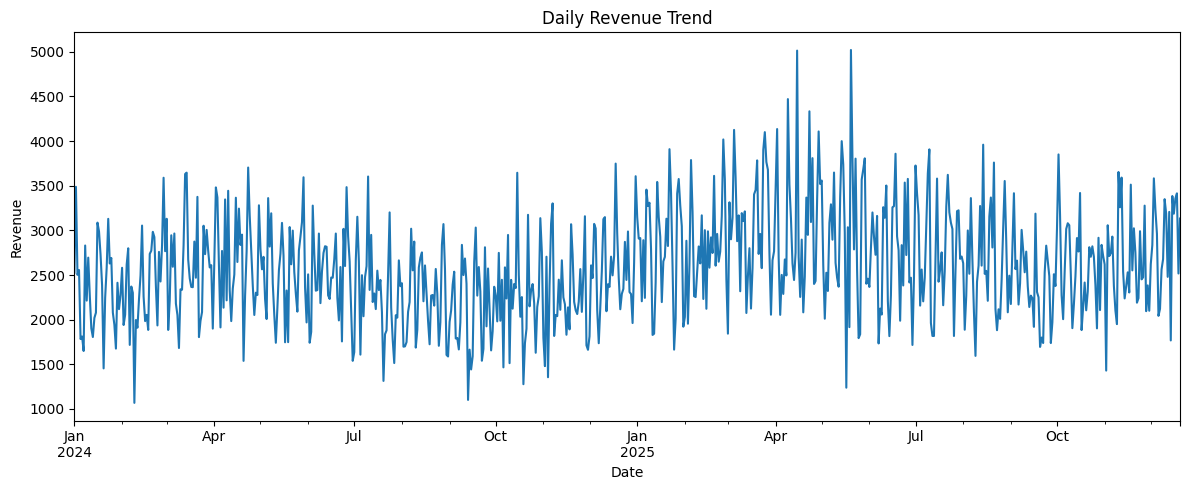

In [6]:
# 5.1 Daily revenue and demand
daily = df.groupby("Date").agg(
    Revenue=("Revenue","sum"),
    Demand=("Quantity","sum"),
    Orders=("InvoiceNo","nunique")
).sort_index()

daily = daily.asfreq("D", fill_value=0)

fig, ax = plt.subplots(figsize=(12,5))
daily["Revenue"].plot(ax=ax)
ax.set_title("Daily Revenue Trend")
ax.set_xlabel("Date")
ax.set_ylabel("Revenue")
plt.tight_layout()
plt.show()


In [7]:
# 5.2 Top products
product_perf = df.groupby(["StockCode","Description"]).agg(
    Revenue=("Revenue","sum"),
    Units=("Quantity","sum"),
    Orders=("InvoiceNo","nunique")
).sort_values("Revenue", ascending=False)

product_perf.head(10)


,,Revenue,Units,Orders
StockCode,Description,,,
P003,Tea Set,"358,848.10",14941,4567
P009,Serving Tray,"310,264.78",14775,4536
P005,Water Bottle,"260,928.54",14483,4487
P004,Lunch Box,"228,945.68",14779,4608
P002,Ceramic Plate,"175,272.55",14624,4546
P006,Storage Jar,"151,100.67",15118,4626
P001,Classic Mug,"123,165.30",14503,4474
P008,Kitchen Towel,"103,558.20",14788,4535
P010,Coffee Spoon,"82,710.73",15031,4580


In [8]:
# 5.3 Top countries
country_perf = df.groupby("Country").agg(
    Revenue=("Revenue","sum"),
    Units=("Quantity","sum"),
    Orders=("InvoiceNo","nunique")
).sort_values("Revenue", ascending=False)

country_perf.head(10)


,Revenue,Units,Orders
Country,,,
France,"315,140.73",25155,7691
Spain,"312,022.26",24766,7641
Germany,"311,769.84",24760,7613
United Kingdom,"308,703.66",24533,7570
Ireland,"308,558.90",24331,7597
Netherlands,"305,158.51",24291,7472


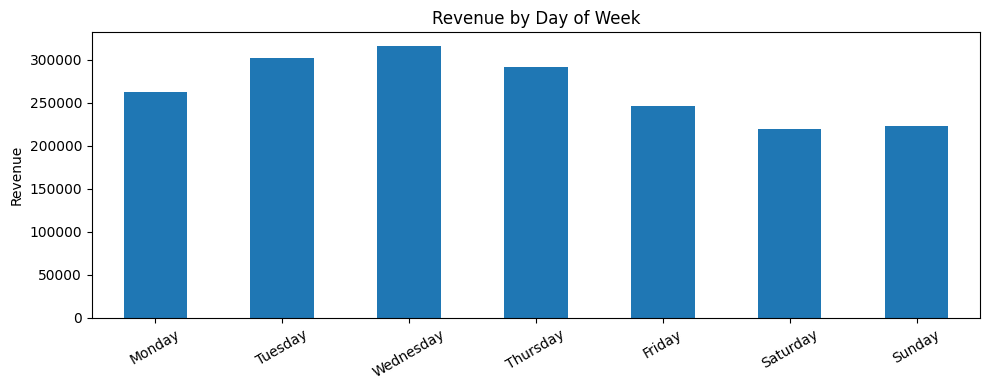

In [9]:
# 5.4 Revenue by weekday
weekday = df.assign(Weekday=df["InvoiceDate"].dt.day_name()).groupby("Weekday")["Revenue"].sum()
weekday = weekday.reindex(["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])

fig, ax = plt.subplots(figsize=(10,4))
weekday.plot(kind="bar", ax=ax)
ax.set_title("Revenue by Day of Week")
ax.set_xlabel("")
ax.set_ylabel("Revenue")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 6. Demand Forecasting

A chronological split is used rather than a random train/test split. Features include:
- previous-day demand,
- 7-day and 14-day lags,
- 7-day and 14-day rolling averages,
- weekday/month,
- time trend.

The model is a `HistGradientBoostingRegressor`, selected because it captures nonlinear relationships while remaining lightweight and easy to reproduce.


In [10]:
# 6.1 Create forecasting features
forecast_df = daily[["Demand","Revenue"]].copy()
forecast_df["lag_1"] = forecast_df["Demand"].shift(1)
forecast_df["lag_7"] = forecast_df["Demand"].shift(7)
forecast_df["lag_14"] = forecast_df["Demand"].shift(14)
forecast_df["rolling_7"] = forecast_df["Demand"].shift(1).rolling(7).mean()
forecast_df["rolling_14"] = forecast_df["Demand"].shift(1).rolling(14).mean()
forecast_df["dow"] = forecast_df.index.dayofweek
forecast_df["month"] = forecast_df.index.month
forecast_df["trend"] = np.arange(len(forecast_df))

feature_cols = ["lag_1","lag_7","lag_14","rolling_7","rolling_14","dow","month","trend"]
model_data = forecast_df.dropna(subset=feature_cols + ["Demand"]).copy()

split = int(len(model_data) * 0.80)
train = model_data.iloc[:split]
test = model_data.iloc[split:]

X_train, y_train = train[feature_cols], train["Demand"]
X_test, y_test = test[feature_cols], test["Demand"]

model = HistGradientBoostingRegressor(
    max_iter=250, learning_rate=0.05, max_leaf_nodes=15,
    l2_regularization=0.2, random_state=RANDOM_STATE
)
model.fit(X_train, y_train)
test["PredictedDemand"] = model.predict(X_test)

mae = mean_absolute_error(y_test, test["PredictedDemand"])
rmse = np.sqrt(mean_squared_error(y_test, test["PredictedDemand"]))
mape = np.mean(np.abs((y_test - test["PredictedDemand"]) / np.maximum(y_test,1))) * 100

print(f"MAE : {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"MAPE: {mape:,.2f}%")


MAE : 30.60
RMSE: 38.21
MAPE: 15.67%


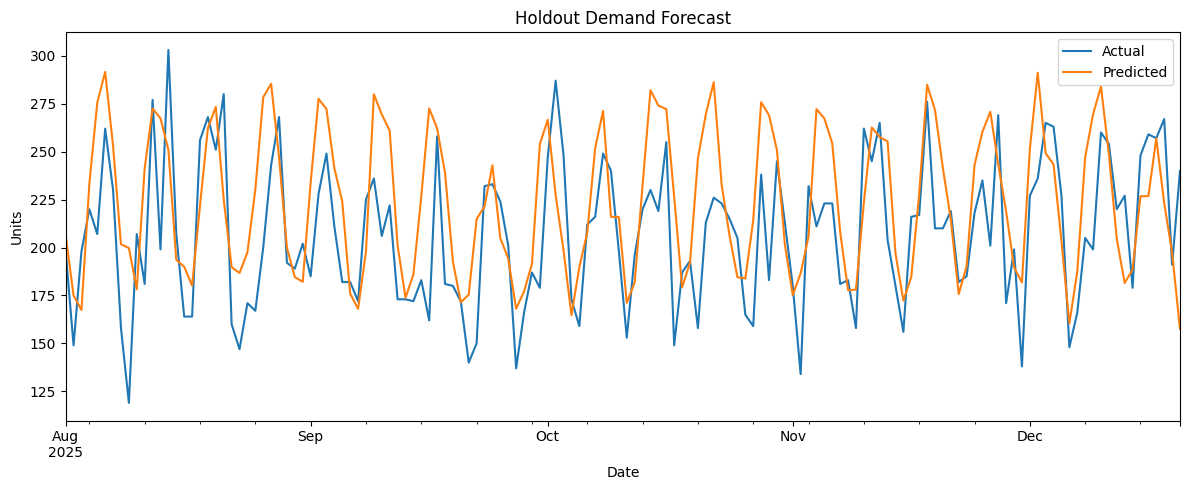

In [11]:
# 6.2 Actual vs predicted demand
fig, ax = plt.subplots(figsize=(12,5))
test["Demand"].plot(ax=ax, label="Actual")
test["PredictedDemand"].plot(ax=ax, label="Predicted")
ax.set_title("Holdout Demand Forecast")
ax.set_xlabel("Date")
ax.set_ylabel("Units")
ax.legend()
plt.tight_layout()
plt.show()


In [12]:
# 6.3 Recursive 30-day forecast
history = daily["Demand"].copy()
future_rows = []

for step in range(1, FORECAST_HORIZON + 1):
    next_date = history.index.max() + pd.Timedelta(days=1)
    row = pd.DataFrame([{
        "lag_1": history.iloc[-1],
        "lag_7": history.iloc[-7] if len(history) >= 7 else history.mean(),
        "lag_14": history.iloc[-14] if len(history) >= 14 else history.mean(),
        "rolling_7": history.iloc[-7:].mean(),
        "rolling_14": history.iloc[-14:].mean(),
        "dow": next_date.dayofweek,
        "month": next_date.month,
        "trend": len(daily) + step
    }], index=[next_date])
    pred = max(0, float(model.predict(row[feature_cols])[0]))
    future_rows.append((next_date, pred))
    history.loc[next_date] = pred

forecast = pd.DataFrame(future_rows, columns=["Date","ForecastDemand"]).set_index("Date")

# A simple model-error band based on holdout residual standard deviation
resid_sd = float((test["Demand"] - test["PredictedDemand"]).std())
forecast["Lower"] = np.maximum(0, forecast["ForecastDemand"] - 1.96*resid_sd)
forecast["Upper"] = forecast["ForecastDemand"] + 1.96*resid_sd

forecast.head(10)


,ForecastDemand,Lower,Upper
Date,,,
2025-12-21,147.41,79.43,215.39
2025-12-22,234.90,166.92,302.88
2025-12-23,262.52,194.54,330.50
2025-12-24,282.83,214.85,350.81
2025-12-25,245.49,177.51,313.47
2025-12-26,176.08,108.10,244.06
2025-12-27,193.54,125.56,261.52
2025-12-28,191.89,123.91,259.87
2025-12-29,224.29,156.31,292.27


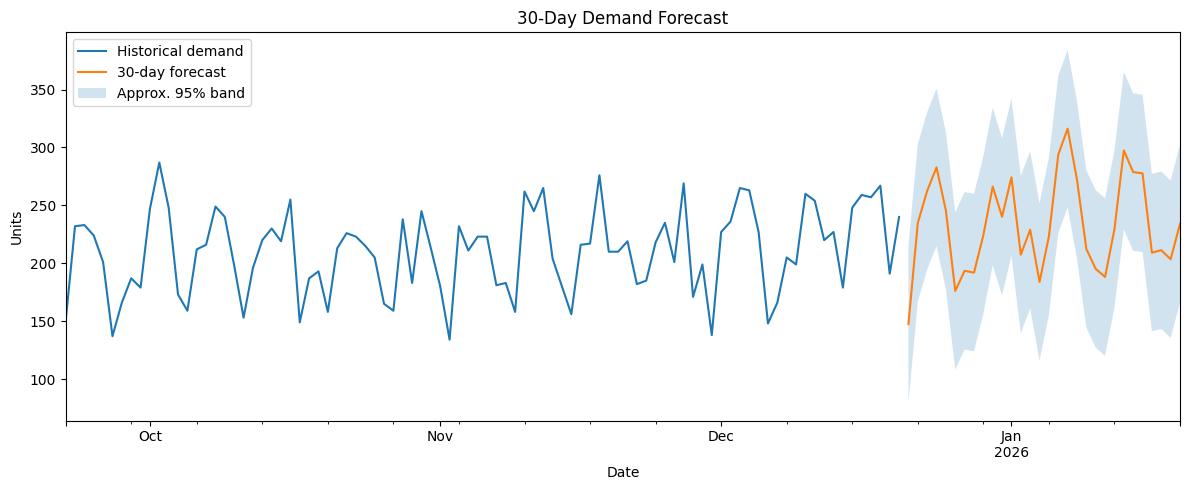

Expected units over next 30 days: 7002.0


In [13]:
# 6.4 Forecast chart
fig, ax = plt.subplots(figsize=(12,5))
daily["Demand"].tail(90).plot(ax=ax, label="Historical demand")
forecast["ForecastDemand"].plot(ax=ax, label="30-day forecast")
ax.fill_between(forecast.index, forecast["Lower"], forecast["Upper"], alpha=0.2, label="Approx. 95% band")
ax.set_title("30-Day Demand Forecast")
ax.set_xlabel("Date")
ax.set_ylabel("Units")
ax.legend()
plt.tight_layout()
plt.show()

print("Expected units over next 30 days:", round(forecast["ForecastDemand"].sum(), 0))


## 7. Demand-Planning Recommendations

The forecast can be translated into an operational planning signal. The simple stock recommendation below uses average forecast demand plus a safety-stock buffer.

This is a planning demonstration, not a replacement for a full inventory optimisation system because lead time, current inventory and supplier constraints are not available in the public transaction dataset.


In [14]:
# 7.1 Basic planning signal
avg_daily_forecast = forecast["ForecastDemand"].mean()
planning_horizon = 7
safety_days = 2

recommended_7_day_units = avg_daily_forecast * planning_horizon
safety_stock = avg_daily_forecast * safety_days
reorder_target = recommended_7_day_units + safety_stock

planning = pd.DataFrame({
    "Planning Metric": [
        "Average forecast daily demand",
        "7-day expected demand",
        "Safety stock (2 days)",
        "Suggested 7-day replenishment target"
    ],
    "Units": [
        avg_daily_forecast,
        recommended_7_day_units,
        safety_stock,
        reorder_target
    ]
})
planning


,Planning Metric,Units
0,Average forecast daily demand,233.40
1,7-day expected demand,"1,633.83"
2,Safety stock (2 days),466.81
3,Suggested 7-day replenishment target,"2,100.64"


## 8. AI Business Chat Assistant

The assistant uses a lightweight NLP pipeline:

**user question → TF-IDF vectorisation → cosine similarity → business intent → analytics function → natural-language answer**

This is intentionally API-free, so the project can run without an external AI key. It can later be connected to a generative LLM for richer explanations.


In [15]:
# 8.1 Define supported business intents
intent_examples = {
    "total_sales": [
        "what are total sales", "how much revenue did we make",
        "show total revenue", "what is our sales value"
    ],
    "top_products": [
        "which products sell the most", "best products",
        "top products by revenue", "what products are performing well"
    ],
    "top_countries": [
        "which countries buy the most", "best markets",
        "top countries by sales", "where are sales highest"
    ],
    "daily_demand": [
        "what is average daily demand", "average units sold per day",
        "how much do we sell each day", "average demand"
    ],
    "forecast": [
        "what is the forecast", "forecast next 7 days",
        "what will demand be next month", "future demand",
        "how much should we expect to sell"
    ],
    "planning": [
        "what should i stock", "how much should i replenish",
        "inventory recommendation", "demand planning recommendation"
    ],
    "trend": [
        "what is the sales trend", "are sales increasing",
        "show sales over time", "sales trend"
    ]
}

intent_texts, intent_labels = [], []
for label, examples in intent_examples.items():
    for ex in examples:
        intent_texts.append(ex)
        intent_labels.append(label)

vectorizer = TfidfVectorizer(stop_words="english", ngram_range=(1,2))
intent_matrix = vectorizer.fit_transform(intent_texts)

def detect_intent(question):
    qv = vectorizer.transform([question])
    scores = cosine_similarity(qv, intent_matrix)[0]
    idx = int(np.argmax(scores))
    return intent_labels[idx], float(scores[idx])

def assistant(question):
    intent, confidence = detect_intent(question)
    if confidence < 0.12:
        return ("I can answer questions about total sales, top products, top countries, "
                "daily demand, forecasts, trends and replenishment planning.", confidence, "unknown")

    if intent == "total_sales":
        answer = f"Total revenue in the cleaned dataset is {total_revenue:,.2f}, across {orders:,} orders."
    elif intent == "top_products":
        top = product_perf.head(5).reset_index()[["Description","Revenue"]]
        answer = "Top products by revenue:\n" + top.to_string(index=False)
    elif intent == "top_countries":
        top = country_perf.head(5).reset_index()[["Country","Revenue"]]
        answer = "Top countries by revenue:\n" + top.to_string(index=False)
    elif intent == "daily_demand":
        answer = f"Average daily demand is {daily['Demand'].mean():,.1f} units, with a maximum of {daily['Demand'].max():,.0f} units on the strongest day."
    elif intent == "forecast":
        horizon = forecast.head(7)
        answer = f"Expected demand over the next 7 days is approximately {horizon['ForecastDemand'].sum():,.0f} units.\n\n" + horizon.to_string()
    elif intent == "planning":
        answer = (f"A simple planning signal is {reorder_target:,.0f} units for a 7-day replenishment target, "
                  f"including approximately {safety_stock:,.0f} units of safety stock. "
                  "A real purchase recommendation should also include current inventory and supplier lead time.")
    elif intent == "trend":
        recent = daily["Revenue"].tail(30).mean()
        prior = daily["Revenue"].tail(60).head(30).mean() if len(daily) >= 60 else daily["Revenue"].head(30).mean()
        change = ((recent-prior)/prior*100) if prior else 0
        direction = "up" if change >= 0 else "down"
        answer = f"Average daily revenue is {direction} by approximately {abs(change):.1f}% comparing the latest 30 days with the preceding 30 days."
    return answer, confidence, intent


In [16]:
# 8.2 Try the AI business assistant
sample_questions = [
    "Which products are performing best?",
    "How much demand should we expect next week?",
    "What should I stock?",
    "Which countries generate the most revenue?",
    "Are sales increasing?"
]

for q in sample_questions:
    ans, conf, intent = assistant(q)
    print("="*80)
    print("USER:", q)
    print("INTENT:", intent, "| CONFIDENCE:", round(conf,3))
    print(ans)


USER: Which products are performing best?
INTENT: top_products | CONFIDENCE: 0.874
Top products by revenue:
  Description    Revenue
      Tea Set 358,848.10
 Serving Tray 310,264.78
 Water Bottle 260,928.54
    Lunch Box 228,945.68
Ceramic Plate 175,272.55
USER: How much demand should we expect next week?
INTENT: forecast | CONFIDENCE: 0.501
Expected demand over the next 7 days is approximately 1,543 units.

            ForecastDemand  Lower  Upper
Date                                    
2025-12-21          147.41  79.43 215.39
2025-12-22          234.90 166.92 302.88
2025-12-23          262.52 194.54 330.50
2025-12-24          282.83 214.85 350.81
2025-12-25          245.49 177.51 313.47
2025-12-26          176.08 108.10 244.06
2025-12-27          193.54 125.56 261.52
USER: What should I stock?
INTENT: planning | CONFIDENCE: 1.0
A simple planning signal is 2,101 units for a 7-day replenishment target, including approximately 467 units of safety stock. A real purchase recommendation 

## 9. Interactive Business Questions

Run the cell below and type a question. Examples:
- `What are total sales?`
- `Which products sell the most?`
- `What is the forecast?`
- `What should I stock?`


In [17]:
# Optional interactive chat loop
# Set RUN_CHAT = True when using the notebook interactively.

RUN_CHAT = False

if RUN_CHAT:
    print("Type 'exit' to stop.")
    while True:
        q = input("Business question: ")
        if q.lower().strip() == "exit":
            break
        answer, confidence, intent = assistant(q)
        print("\nAssistant:", answer)
        print("Detected intent:", intent, "| confidence:", round(confidence,3))


## 10. Key Findings & Recommendations

The project demonstrates an end-to-end analytics workflow:

- Transaction-level data can be converted into daily demand and revenue KPIs.
- Product and country rankings reveal where commercial performance is concentrated.
- Chronological machine-learning forecasting supports short-term demand planning.
- Forecast uncertainty should be considered when setting replenishment buffers.
- The AI assistant reduces the time needed to obtain routine business insights.

### Recommended next steps for a production system
1. Add current inventory, lead time and supplier minimum order quantities.
2. Forecast at SKU level instead of only total daily demand.
3. Add promotions, holidays and price changes as external features.
4. Track forecast accuracy continuously.
5. Connect the assistant to a database/dashboard and a governed generative AI model.
6. Add authentication and role-based access before deployment.


## 11. Conclusion

This project demonstrates how **data analytics + machine learning + NLP/AI** can be combined into a practical retail decision-support system. The final workflow moves from raw transactions to business KPIs, forecasting, demand-planning recommendations and natural-language business interaction.
